# Factor Validation

En este notebook se analizan las propiedades estadísticas y temporales de los factores construidos en la fase de *Feature Engineering*.

El objetivo es evaluar la calidad, estabilidad, persistencia y redundancia de cada factor antes de su utilización en modelos de selección de activos y construcción de carteras.

Los resultados obtenidos servirán para justificar las decisiones de preprocesamiento (winsorización, normalización, etc.) y la posible eliminación de factores redundantes.

In [34]:
import sys
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from pathlib import Path
from scipy import stats
from matplotlib.ticker import PercentFormatter

# adds the root carpet of the project to the sys.path to allow importing modules from src
sys.path.append(str(Path.cwd().parent))

# autoreload configuration to automatically reload modules when they are modified
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Carga de Datos e inspección

In [3]:
prices = pd.read_parquet("../data/raw/sp500_prices.parquet")

# base variables
simple_returns = pd.read_parquet("../data/processed/simple_returns.parquet")
log_returns = pd.read_parquet("../data/processed/log_returns.parquet")
cumulative_returns = pd.read_parquet("../data/processed/cumulative_returns.parquet")

# style factors
momentum_12_1 = pd.read_parquet("../data/processed/momentum_12_1.parquet")
short_term_reversal = pd.read_parquet("../data/processed/short_term_reversal.parquet")
rolling_volatility = pd.read_parquet("../data/processed/rolling_volatility.parquet")
upside_volatility = pd.read_parquet("../data/processed/upside_volatility.parquet")
downside_volatility = pd.read_parquet("../data/processed/downside_volatility.parquet")
amihud_illiquidity = pd.read_parquet("../data/processed/amihud_illiquidity.parquet")


### 1.1 Información general por factor

In [4]:
factors = {
    "momentum_12_1": momentum_12_1,
    "short_term_reversal": short_term_reversal,
    "rolling_volatility": rolling_volatility,
    "upside_volatility": upside_volatility,
    "downside_volatility": downside_volatility,
    "amihud_illiquidity": amihud_illiquidity,
}

for name, df in factors.items():
    print(f"{name}")
    df.info()
    print("-" * 80)



momentum_12_1
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
--------------------------------------------------------------------------------
short_term_reversal
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
--------------------------------------------------------------------------------
rolling_volatility
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
--------------------------------------------------------------------------------
upside_volatility
<class 'pandas.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Columns: 499 entries, A to ZTS
dtypes: float64(499)
memory usage: 14.4 MB
------------------------------------------------------------------

## 2. Análisis de Cobertura y Calidad de Datos (Data Quality)

   - Porcentaje de valores nulos (NaNs) por factor y por fecha.
   - Nº de activos válidos en la cross-section a lo largo del tiempo.
   - Identificación de sesgo de supervivencia o inicio de series (Warm-up period por rolling windows).

### 2.1 Matriz de cobertura por factor y warm-up days

In [5]:
from src.analysis.factor_diagnostics import get_warmup_trading_days 

factors = {
    "momentum_12_1": momentum_12_1,
    "short_term_reversal": short_term_reversal,
    "rolling_volatility": rolling_volatility,
    "upside_volatility": upside_volatility,
    "downside_volatility": downside_volatility,
    "amihud_illiquidity": amihud_illiquidity,
}

summary = pd.DataFrame(
    [
        {
            "factor": name,
            "total_values": df.size,
            "valid_values": df.notna().sum().sum(),
            "nan_percentage": df.isna().sum().sum() / df.size * 100,
            "global_start_date": (
                df.index.get_level_values("Date")[df.notna().any(axis=1)].min()
            ),
            "global_end_date": (
                df.index.get_level_values("Date")[df.notna().any(axis=1)].max()
            ),
            "warmup_trading_days": get_warmup_trading_days(df),
        }
        for name, df in factors.items()
    ]
).set_index("factor")

summary["nan_percentage"] = summary["nan_percentage"].round(2)

summary

,total_values,valid_values,nan_percentage,global_start_date,global_end_date,warmup_trading_days
factor,,,,,,
momentum_12_1,1882727,1644211,12.67,2011-01-03,2024-12-30,252
short_term_reversal,1882727,1759361,6.55,2010-02-03,2024-12-30,21
rolling_volatility,1882727,1644211,12.67,2011-01-03,2024-12-30,252
upside_volatility,1882727,1747377,7.19,2010-02-16,2024-12-30,29
downside_volatility,1882727,1745649,7.28,2010-02-12,2024-12-30,28
amihud_illiquidity,1882727,1757181,6.67,2010-01-26,2024-12-30,15


Como era de esperar, los warming up days del Momentum y de la Rolling volatility son de un año completo ya que ambos factores se han definido con una ventana de 252 días. Concretamente en el caso del Momentum, este factor calculado el día t necesita el precio del día $(t-252)$ por lo que esos warm-up days son insalvables. 

En el caso de la rolling volatility sí que se podría haber definido un periodo mínimo de 30 o 60 días para poder calcular un valor de la Volatilidad sin la necesidad de que pase un año completo, pero, aprovechando que este factor no tiene valores NaN internos y que tenemos varios años de datos para todas las empresas, hemos exigido que todos los 252 periodos tengan datos para calcular el factor. La consecuencia obviamente es que los primeros 251 días de cotización de la empresa no tendremos un valor para la volatilidad, pero cuando lo tengamos nos habremos asegurado de que es lo suficientemente sólido y robusto. 

En el caso de Amihud Illiquidity sí que hemos elegido un periodo mínimo de 15 días para una ventana de 21 y en el caso del Short Term Reversal el cálculo nos exige el lag 21 por lo que tampoco tenemos opción. 

Por último las dos volatilidades (Upside y Downside) funcionan con una ventana de 252 días pero con un periodo mínimo de 21 días ya que, como cada una solamente tiene en cuenta los retornos de un signo

### 2.2 Análisis de cobertura por factor

A continuación se muestra gráficamente la evolución temporal del número de empresas disponibles para cada uno de los factores. Como todos ellos siguen prácticamente la misma evolución se ha considerado, a modo de representación, dos factores que obedezcan los dos rangos de warm up days que tenemos (1 mes y 1 año). Concretamente se ha elegido el Momentum y el Anihud Illiquidity. 

El número de puntos corresponde a uno por mes, siendo este el valor del último día de su mes correspondiente. 

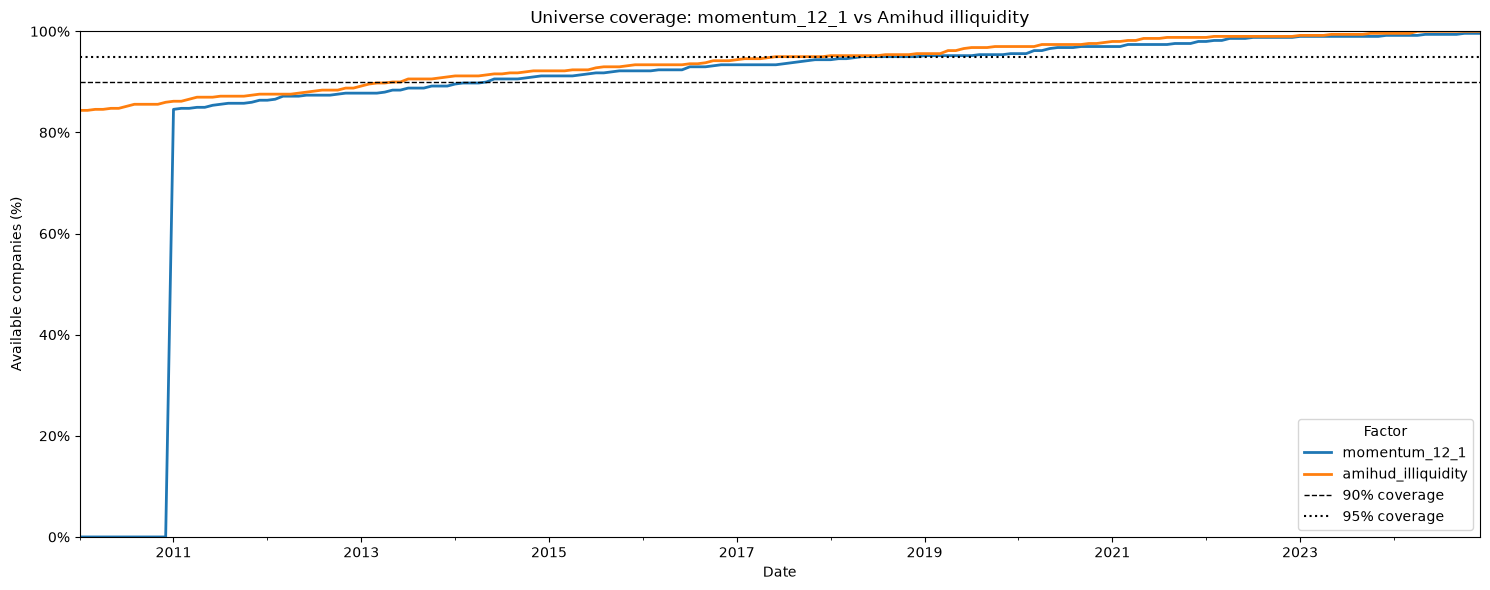

In [6]:
from src.analysis.factor_diagnostics import factor_coverage_since_first_valid

selected_factors = {
    "momentum_12_1": momentum_12_1,
    "amihud_illiquidity": amihud_illiquidity,
}

daily_factor_coverage = pd.DataFrame(
    {
        name: factor_coverage_since_first_valid(df, total_companies=499)
        for name, df in selected_factors.items()
    }
)

monthly_factor_coverage = daily_factor_coverage.resample("ME").last()

ax = monthly_factor_coverage.plot(
    figsize=(15, 6),
    linewidth=2,
    ylabel="Available companies (%)",
    title="Universe coverage: momentum_12_1 vs Amihud illiquidity",
)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.legend(title="Factor")

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

ax.axhline(y=90, color="black", linestyle="--", linewidth=1, label="90% coverage")
ax.axhline(y=95, color="black", linestyle=":", linewidth=1.5, label="95% coverage")

ax.legend(title="Factor")


plt.tight_layout()
plt.show()

La diferencia en el número de warm up days entre los dos factores se ve clara ya que se muestra que prácticamente hasta 2011 el Momentum no tiene ninguna empresa disponible mientras que el Amihud Illiquidity comienza a rodar desde más del 80%. La subida vertical corresponde al día en el que la gran mayoría de empresas cumplieron los 252 días cotizados y se ve cómo a partir de ese momento los dos factores crecen en porcentaje de empresas disponibles de forma paulatina y al mismo ritmo. 

Entre el 2013 y el 2015 se llega al 90% de empresas disponibles y entre 2017 y 2019 se alcanza el 95%. 

### 2.3 Análisis de los valores NaN

Analizaremos en profundidad la cantidad y la distribución de los valores NaN dentro de las series de nuestros factores. 

In [7]:
from src.analysis.factor_diagnostics import internal_nan_count_by_ticker

print("Total NaNs after first valid by ticker:")

nans_by_factor = pd.Series(
    {
        name: internal_nan_count_by_ticker(df).sum()
        for name, df in factors.items()
    },
    name="nans_after_first_valid_by_ticker",
)

nans_by_factor

Total NaNs after first valid by ticker:


momentum_12_1             0
short_term_reversal       0
rolling_volatility        0
upside_volatility      1047
downside_volatility    1219
amihud_illiquidity     4190
Name: nans_after_first_valid_by_ticker, dtype: int64

Para los tres primeros factores (momentum, short term reversal y rolling volatility) observamos justo lo esperado, cero valores NaN internos. Es decir que, todos los NaN se acumulan al principio de la serie y no encontramos ninguna a partir del primer valor válido para cada Ticker. Realmente esto ya lo medio comprobamos al validar la data ya que nos aseguramos que no encontrábamos en el data frame de precios ningún NaN interno. 

Por otro lado sí que vamos a obervar NaNs en el upside y downside volatility y en el amihud illiquidity. Esto tiene sentido ya que la upside y downside volatility se calculan teniendo en cuenta una ventana de 252 días poniendo de restricción un mínimo de 21 días válidos. Por lo tanto, si entramos en una mala racha en el que hay muchos días seguidos con retornos negativos, la Upside volatility va a empezar a dar valores NaN. 

En el tema del Amihud Iliquidity, esos valores NaN se explican por los volúmenes nulos. La función tiene como restricción que solo se pueda dar un valor válido si de la ventana de 21 días que considera, al menos 15 son válidos, por el contrario daría NaN. 

A pesar de que podamos considerar que la cantidad de NaNs en los tres factores es suficientemente pequeña en comparación a la cantidad de valores que manejamos, realizaremos un análisis exhaustivo en ambas dimensiones: temporal y cross-sectional. 

####  2.3.1 Análisis temporal (NaNs por día y por trimestre)

En primer lugar, vamos a graficar el número de NaNs diarios (sumando los de todas las empresas) para el Upside y para el Downdside Volatility. Así podremos ver la evolución del porcentaje de NaNs en el tiempo. 

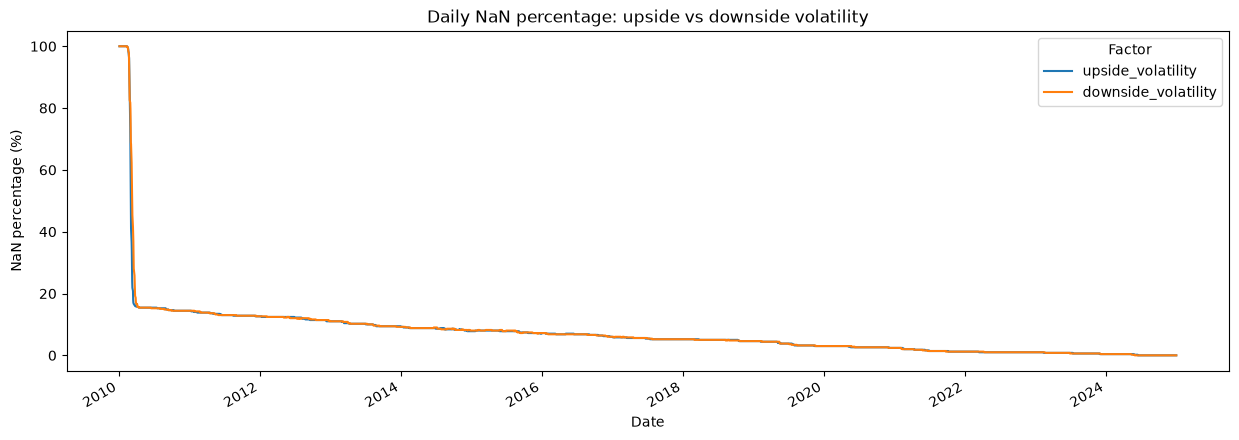

In [8]:
daily_nan_comparison_pct = pd.DataFrame(
    {
        "upside_volatility": (
            upside_volatility.isna().sum(axis=1)
            / upside_volatility.shape[1]
            * 100
        ),
        "downside_volatility": (
            downside_volatility.isna().sum(axis=1)
            / downside_volatility.shape[1]
            * 100
        ),
    }
)

ax = daily_nan_comparison_pct.plot(
    kind="line",
    figsize=(15, 5),
    linewidth=1.5,
    ylabel="NaN percentage (%)",
    title="Daily NaN percentage: upside vs downside volatility",
)

ax.legend(title="Factor")
plt.show()

Vemos exactamente lo que se esperaba: el primer mes el porcentaje de NaNs es del 100% ya que ninguna empresa, a pesar de empezar a cotizar el día uno, tiene el suficiente número de días como para que los indicadores de Upside y Donside Volatility den un valor distinto del NaN. 

Se ve justamente que al pasar esa barrera de los 29 y 28 días respectivamente, el número de NaNs de las dos volatilidades caen en picado hasta situarse por debajo del 20%. Esto se explica porque la gran mayoría de las empresas de nuestro Universo ya estaban cotizando desde el primer día que consideramso como inicio del intervalo con el que trabajamos. Después se ve cómo progresivamente el número de NaNs va cayendo hasta llegar en 2024 a menos del 10%. 

Sin embargo, lo único que podemos concluir a partir de este gráfico es que la gran mayoría de NaNs provienen del tiempo en el que las empresas no cotizaban, es decir, que la proporción de NaNs internos es bastante inferior a la de NaNs antes de cotización. Realmente para poder ver la distribución de los NaNs internos tenemos que no considerar el otro tipo. 

El siguiente gráfico agrupa por trimestres el número de NaNs presentes en cada una de las volatilidades. La diferencia es que ahora solamente se contabilizan los NaNs de las empresas que ya han tenido al menos un día de cotización distinto del NaN, así nos aseguramos de solo incluir los internos. 

<Axes: title={'center': 'Quarterly internal NaNs: upside vs downside volatility'}, xlabel='Date', ylabel='Internal NaN count'>

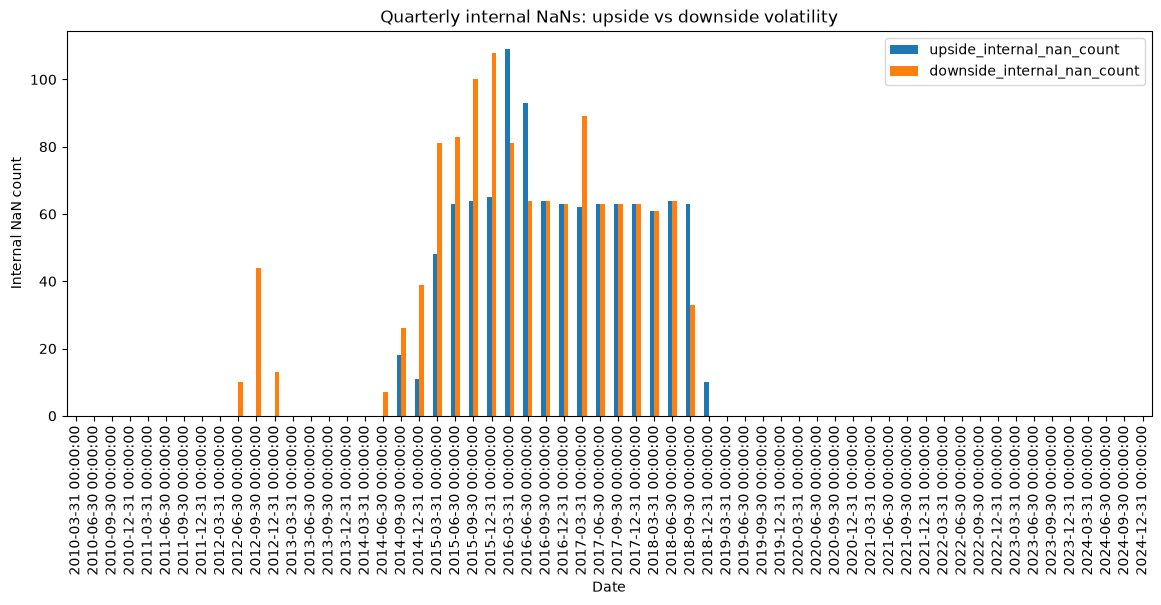

In [9]:
from src.analysis.factor_diagnostics import internal_nans_by_quarter

upside_quarterly = internal_nans_by_quarter(upside_volatility).add_prefix("upside_")
downside_quarterly = internal_nans_by_quarter(downside_volatility).add_prefix("downside_")

volatility_nan_comparison = pd.concat(
    [upside_quarterly, downside_quarterly],
    axis=1,
)

volatility_nan_comparison[
    ["upside_internal_nan_count", "downside_internal_nan_count"]
].plot(
    kind="bar",
    figsize=(14, 5),
    ylabel="Internal NaN count",
    title="Quarterly internal NaNs: upside vs downside volatility",
)

Observamos que el número de NaNs por trimestres se concentran entre el año 2014 y 2017. Después cuando analicemos la otra dimension (en vez de temporal, por empresa) obtendremos más información. 

Igualmente estos números no preocupan ya que el máximos de NaNs que llegamos a tener en un trimestre son de en torno a unos 100 para ambos factores y teniendo en cuenta que en un trimestre tenemos por factor unas 30000 observaciones (63 días por las 499 empresas), la proporción es ridícula. 


Realizaremos la misma gráfica para el último factor Amihud Illiquidity para ver la evolución temporal del número de NaNs.  

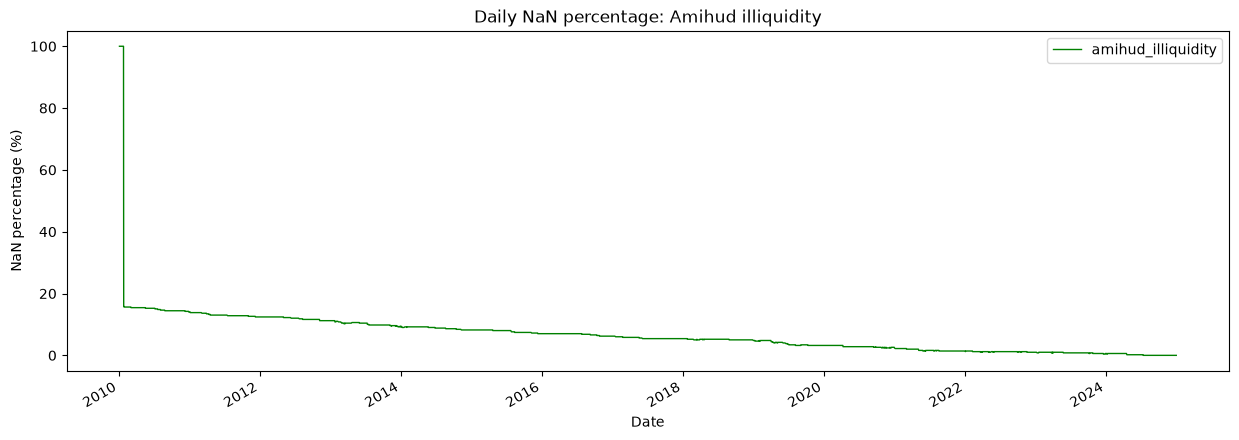

In [10]:
daily_amihud_nan_pct = (
    amihud_illiquidity.isna().sum(axis=1)
    / amihud_illiquidity.shape[1]
    * 100
)

ax = daily_amihud_nan_pct.plot(
    kind="line",
    figsize=(15, 5),
    linewidth=1,
    ylabel="NaN percentage (%)",
    title="Daily NaN percentage: Amihud illiquidity",
    color="green"
)

ax.legend(["amihud_illiquidity"])
plt.show()

Comprobamos el mismo comportamiento, el número de NaNs comienza siendo máximo hasta que se cumplen el periodo mínimo de 15 días y el número de NaNs cae drásticamente. 

#### 2.3.2 Análisis cross-sectional (NaNs por empresa)

Podemos comprobar también el número de NaNs por empresa. Lo que haremos es identificar el top 3 de empresas con mayor número de NaNs totales para cada uno de los tres factores que nos conciernen: Upside y Downside Volatility y Amihud Illiquidity (los otro tres no presentan NaNs internos). 

Los otros tres factores no presentan valores NaN internos. 

In [11]:
selected_factors = {
    "upside_volatility": upside_volatility,
    "downside_volatility": downside_volatility,
    "amihud_illiquidity": amihud_illiquidity,
}

top3_internal_nans_selected = pd.concat(
    {
        factor_name: internal_nan_count_by_ticker(df).head(3)
        for factor_name, df in selected_factors.items()
    },
    names=["factor", "ticker"],
).to_frame("internal_nan_count")

top3_internal_nans_selected

internal_nan_count
factor              ticker                    
upside_volatility   AMCR                   940
                    SW                     107
                    VRSN                     0
downside_volatility AMCR                   925
                    SW                     294
                    VRSN                     0
amihud_illiquidity  SW                    2677
                    AMCR                  1513
                    VRSN                     0

Podemos darnos cuenta que los NaNs internos no están distribuidos homogéneamente entre empresas sino que se concentran, para los tres factores, en dos únicas empresas: AMCR (Amcor plc) y SW (Smurfit Westrock plc)

### 2.3 Conclusiones y decisiones de limpieza 

1. Diagnóstico e Integridad de la Serie (Filtros del Universo)

Durante el análisis de calidad de datos, se identificaron dos activos (AMCR — Amcor plc y SW — Smurfit Westrock plc) que presentaban inconsistencias graves en su registro histórico. Específicamente, se detectaron períodos prolongados de volumen de negociación nulo, tramos totalmente planos en los precios ajustados y discontinuidades anómalas en los factores de volatilidad (upside/downside volatility).

Estas anomalías obedecen a eventos corporativos (fusiones y reestructuraciones) que derivaron en la creación de nuevos tickers con datos históricos reconstruidos sintéticamente. Dado que estos tramos no reflejan un activo negociado de forma continua en el mercado, se ha decidido excluir ambas compañías del universo de inversión, evitando así introducir señales artificiales o distorsiones en el cálculo de los factores.

2. Definición del Período de Análisis Limpio (Warm-up)

El período oficial de análisis comienza a partir del cumplimiento de las primeras 252 sesiones bursátiles del dataset. Este umbral corresponde a la ventana de observación (lookback window) más exigente de los factores construidos (como el Momentum 12-1 o la Volatilidad Histórica a 252 días).

De este modo, se garantiza que la totalidad de los factores de ventana móvil estén plenamente definidos y que la cobertura transversal (cross-sectional) sea estable y homogénea desde la primera fecha efectiva del estudio, habiendo descartado por completo la fase de warm-up.

In [12]:
# decisions from the diagnostics
tickers_to_remove = ["SW", "AMCR"]
analysis_start_date = prices.index[252]

# dataset cleaning based on the diagnostics results
prices_clean = prices.loc[analysis_start_date:].drop(
    columns=tickers_to_remove, level=1, errors="ignore"
)

momentum_12_1_clean = momentum_12_1.loc[analysis_start_date:].drop(columns=tickers_to_remove)

short_term_reversal_clean = short_term_reversal.loc[analysis_start_date:].drop(columns=tickers_to_remove)

rolling_volatility_clean = rolling_volatility.loc[analysis_start_date:].drop(columns=tickers_to_remove)

upside_volatility_clean = upside_volatility.loc[analysis_start_date:].drop(columns=tickers_to_remove)

downside_volatility_clean = downside_volatility.loc[analysis_start_date:].drop(columns=tickers_to_remove)

amihud_illiquidity_clean = amihud_illiquidity.loc[analysis_start_date:].drop(columns=tickers_to_remove)

## 3. Análisis de Distribución (Univariado)

### Tabla consolidada de estadísticos globales

In [13]:
factors_clean = {
    "momentum_12_1": momentum_12_1_clean,
    "short_term_reversal": short_term_reversal_clean,
    "rolling_volatility": rolling_volatility_clean,
    "upside_volatility": upside_volatility_clean,
    "downside_volatility": downside_volatility_clean,
    "amihud_illiquidity": amihud_illiquidity_clean,
}

summary = []

for name, df in factors_clean.items():

    values = df.stack().dropna()

    summary.append({
        "Factor": name,
        "Mean": values.mean(),
        "Std": values.std(),
        "Min": values.min(),
        "P25": values.quantile(0.25),
        "P50": values.median(),
        "P75": values.quantile(0.75),
        "Max": values.max(),
        "Skewness": values.skew(),
        "Kurtosis": values.kurt()
    })

summary_table = (
    pd.DataFrame(summary)
      .set_index("Factor")
)

summary_table.map(lambda x: f"{x:.4g}")

,Mean,Std,Min,P25,P50,P75,Max,Skewness,Kurtosis
Factor,,,,,,,,,
momentum_12_1,0.1724,0.3413,-0.98,-0.01466,0.1392,0.3067,11.51,3.918,54.3
short_term_reversal,0.01497,0.08754,-0.8717,-0.03093,0.01473,0.05894,2.185,0.5552,11.6
rolling_volatility,0.01827,0.008023,0.003277,0.01283,0.01627,0.02152,0.1138,2.087,8.756
upside_volatility,0.0123,0.006103,0.002316,0.008199,0.01069,0.0147,0.0928,2.211,9.343
downside_volatility,0.01326,0.006899,0.002321,0.008851,0.01144,0.0155,0.09549,2.659,13.84
amihud_illiquidity,3.144e-10,4.308e-09,3.571e-13,4.146e-11,8.516e-11,1.697e-10,7.271e-07,86.1,1.047e+04


El análisis de los estadísticos univariados consolidados sobre la muestra limpia revela heterogeneidades severas en la escala, asimetría y densidad de las colas de los factores, aportando una prueba empírica concluyente para el posterior preprocesamiento de datos. Destaca en primer lugar una acusada disparidad en las magnitudes físicas del panel, donde el momentum a doce meses se expresa en retornos acumulados anuales con una media del 17.24%, las volatilidades se sitúan en rangos diarios medios del 1.23% al 1.82%, y la iliquidez de Amihud se mueve en micro-escalas con una mediana de $8.516 \times 10^{-11}$. Esta dispersión de órdenes de magnitud confirma que las variables resultan incommensurables entre sí sin la aplicación previa de una estandarización transversal.

El hallazgo más crítico del diagnóstico reside en la iliquidez de Amihud, cuya asimetría de 86.1 y curtosis de 10,470 —si bien se han reducido sustancialmente tras el filtrado de calidad inicial— continúan reflejando un comportamiento extremadamente sesgado a la derecha. Este fenómeno es inherente a jornadas de volumen de negociación residual en ciertos activos, donde divisiones por un denominador cercano a cero generan picos de escala impredecibles que hacen imprescindible una transformación logarítmica o un filtrado riguroso de valores atípicos. Por su parte, el momentum_12_1 exhibe un marcado sesgo positivo con una curtosis de 54.3 y un valor máximo del 1,151%, representativo de activos con comportamientos parabólicos en el periodo analizado, frente a un límite inferior de -98% que respeta de forma coherente el suelo teórico del -100%.

En lo relativo a los factores de volatilidad, la comparación entre componentes direccionales confirma la presencia del efecto apalancamiento (leverage effect), observándose que la downside volatility presenta una media ligeramente superior (1.326%) respecto a la upside volatility (1.230%), acompañada de una mayor curtosis (13.84 frente a 9.34) y asimetría (2.659 frente a 2.211), lo que demuestra que las perturbaciones negativas en el mercado generan colas más anchas e intensas. En el extremo opuesto, el factor de reversión a corto plazo se consolida como la métrica más simétrica y estable del panel, con una media cercana a cero y una curtosis de 11.60. En conjunto, la persistencia de estos valores extremos y la incompatibilidad de escalas exigen de forma obligatoria la estandarización transversal por puntuación Z y la aplicación de un proceso de winsorizing en cada sección cruzada antes de acometer cualquier fase de modelado.

### 3.1 Análisis de la Distribución de Factores (Histogramas)

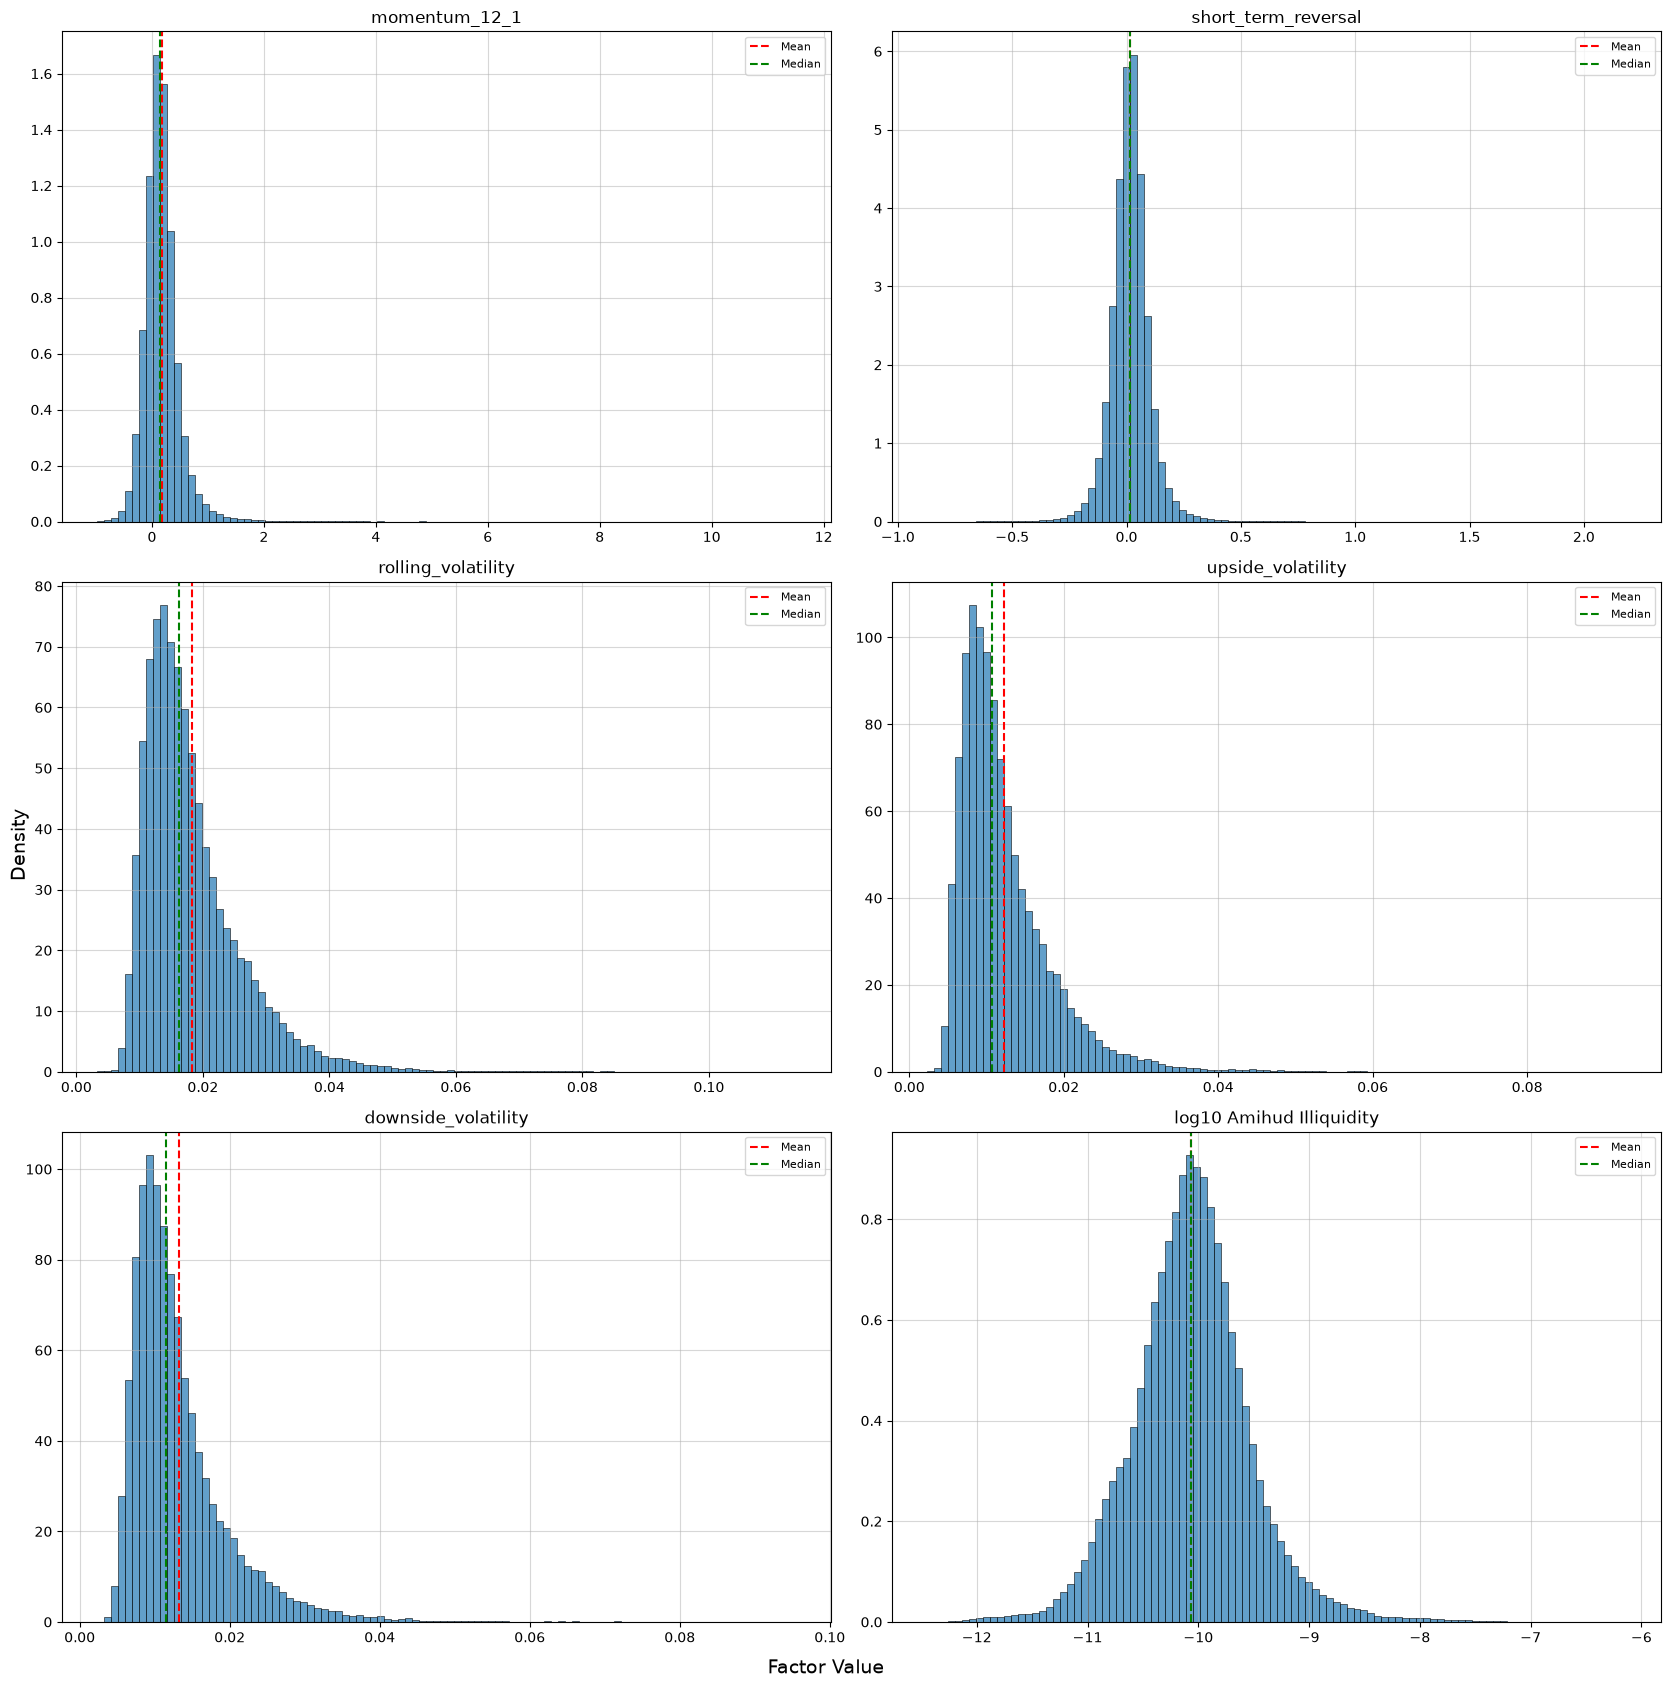

In [39]:
fig, axes = plt.subplots(3, 2, figsize=(17, 17))
axes = axes.flatten()

for ax, (name, df) in zip(axes, factors_clean.items()):

    values = df.stack().dropna()

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        values = np.log10(values[values > 0])   # avoid issues with zeros
        title = "log10 Amihud Illiquidity"
        xlabel = "log10(Amihud)"
    else:
        title = name
        xlabel = "Factor value"

    sns.histplot(
    values,
    bins=100,
    kde=False,
    stat="density",
    edgecolor="black",
    alpha=0.7,
    ax=ax
)

    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.5)
    ax.set_ylabel("")
    ax.axvline(values.mean(), color="red", linestyle="--",
           linewidth=1.5, label="Mean")
    ax.axvline(np.median(values), color="green", linestyle="--",
           linewidth=1.5, label="Median")
    ax.legend(fontsize=8)

fig.supxlabel("Factor Value", fontsize=14)
fig.supylabel("Density", fontsize=14)

plt.tight_layout()
plt.show()

El análisis visual mediante histogramas confirma los patrones observados en los estadísticos descriptivos, mostrando distribuciones alejadas de la normalidad teórica y revelando los sesgos característicos de cada métrica financiera. Se prescinde de las curvas de estimación de densidad por kernel (KDE) debido a que, al trabajar con una muestra de gran tamaño y fijar un número elevado de bins en los histogramas, la resolución discreta aproxima de forma casi exacta la función de densidad subyacente.

En primer lugar, la aplicación de la transformación **$\log_{10}$ al factor `amihud_illiquidity**` permite resolver la compresión extrema que sufría en su escala original. Al trasponer los datos a escala logarítmica, la distribución abandona la "L" o pared vertical original para desplegar una campana continua y bien definida, centrada en torno a su mediana (alrededor de $-10.07$ en escala base 10). No obstante, el gráfico sigue mostrando una asimetría positiva moderada y una cola derecha extendida hacia valores menos negativos ($\log_{10} \approx -6.14$), correspondiente a aquellas jornadas o activos con niveles de iliquidez atípicamente elevados. Esta visualización confirma que la transformación logarítmica es completamente acertada y necesaria para estabilizar la varianza del factor antes de su procesamiento.

Por su parte, los tres factores de volatilidad (**`rolling_volatility`**, **`upside_volatility`** y **`downside_volatility`**) exhiben distribuciones asimétricas positivas bien definidas. Al estar delimitadas inferiormente por el cero, las masas de probabilidad crecen rápidamente hasta alcanzar sus picos alrededor del 1.0%–1.6% diario, para posteriormente decaer suavemente hacia la derecha. Destaca de forma muy clara la diferencia visual entre las dos volatilidades direccionales: la **`downside_volatility`** dibuja una cola derecha significativamente más larga, gruesa y distante del cuerpo central que la **`upside_volatility`**, plasmando gráficamente el pico de dispersión que sufren los activos durante las jornadas de pánico bursátil.

En el caso del **`momentum_12_1`**, el gráfico muestra un cuerpo central desplazado ligeramente hacia la derecha del cero, con un suelo rígido en el $-0.98$ que frena abruptamente la cola izquierda. Resulta especialmente interesante comparar la estructura del *momentum* con la de las volatilidades o la del propio *Amihud*: si bien alcanza un valor máximo absoluto muy elevado ($11.51$), el gráfico no exhibe una cola derecha estirada de forma uniforme como en las volatilidades, ni una distancia tan acusada entre su media ($0.1724$) y su mediana ($0.1392$). Esto obedece a que su elevadísima curtosis ($54.3$) concentra a la abrumadora mayoría de los datos en torno a la moda central, haciendo que los valores extremos actúen como observaciones atípicas aisladas (*outliers* lejanos) más que como una masa continua de cola ancha.

Finalmente, el factor **`short_term_reversal`** es el único del conjunto que muestra una forma visual cercana a una campana simétrica centrada prácticamente en el cero. Sin embargo, a diferencia de una distribución Normal estándar, el histograma revela un pico central extremadamente agudo y alto —consecuencia directa de su curtosis de 11.60— acompañado de caídas muy rápidas hacia los lados, lo que constata una gran concentración de retornos diarios neutros interrumpida únicamente por shocks puntuales en las colas.

### 3.2 Análisis de las gráficas QQ plots por factores

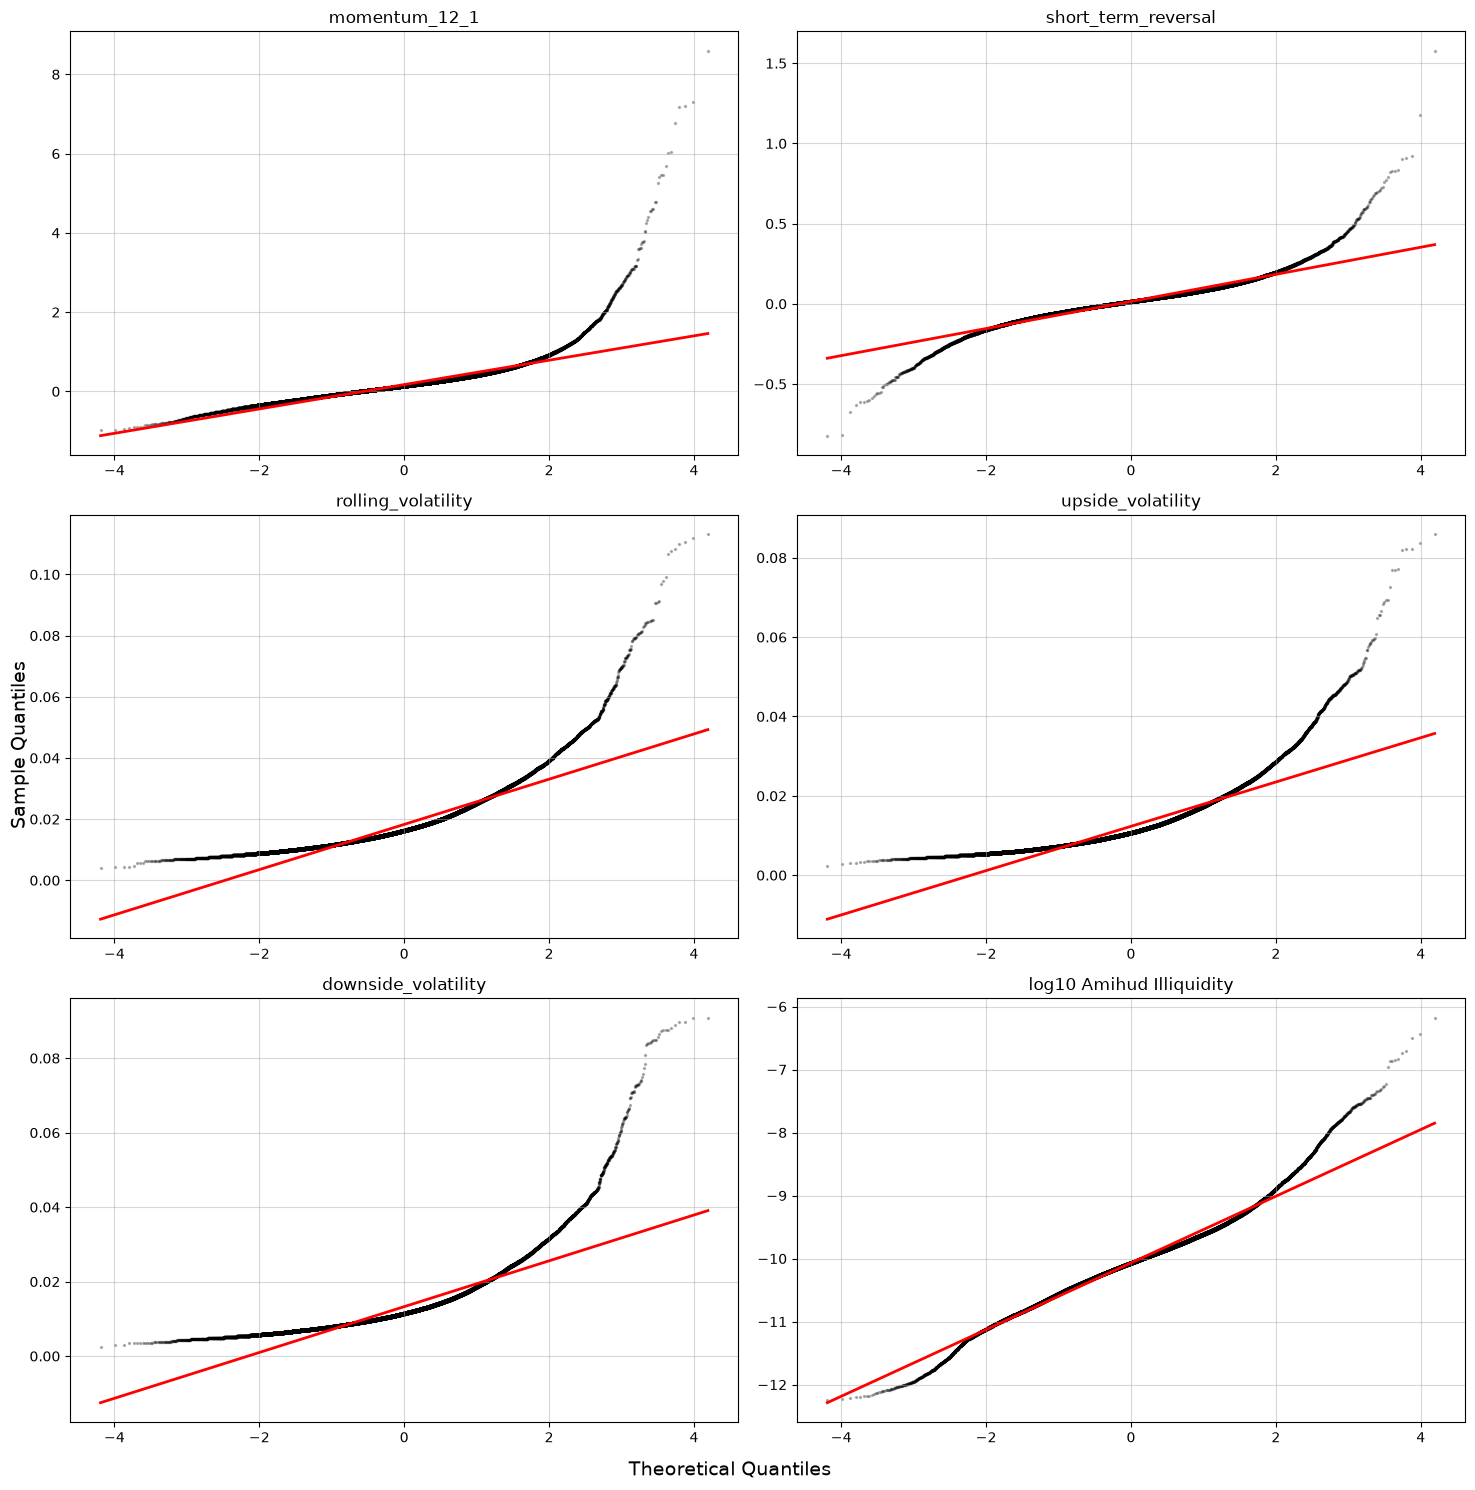

In [42]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for ax, (name, df) in zip(axes, factors_clean.items()):

    values = df.stack().dropna()

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        values = np.log10(values[values > 0])
        title = "log10 Amihud Illiquidity"
    else:
        title = name

    # Sample 50,000 observations for visualization
    if len(values) > 50000:
        values = values.sample(50000, random_state=42)

    # Compute QQ plot data
    (osm, osr), (slope, intercept, r) = stats.probplot(values, dist="norm")

    # Scatter points
    ax.scatter(
        osm,
        osr,
        s=8,
        color="black",
        alpha=0.25,
        marker="."
    )

    # Reference line
    ax.plot(
        osm,
        slope * osm + intercept,
        color="red",
        linewidth=2
    )

    ax.set_title(title, fontsize=12)
    ax.grid(alpha=0.5)

fig.supxlabel("Theoretical Quantiles", fontsize=14)
fig.supylabel("Sample Quantiles", fontsize=14)

plt.tight_layout()
plt.show()

El análisis de los gráficos Q-Q confirma la presencia de colas pesadas y el incumplimiento severo de la normalidad gaussiana en todos los factores. En **`log10_amihud`**, aunque la transformación logarítmica logra acoplar el cuerpo central a la recta teórica, ambas colas terminan divergiendo de la diagonal, mostrando una desviación sensiblemente más acusada en el extremo derecho producto de picos persistentes de iliquidez. En el caso del **`momentum_12_1`**, la cola izquierda se adhiere con fidelidad a la Normal —frenada por el límite económico insuperable del $-100\%$—, mientras que el extremo derecho se dispara verticalmente debido a la presencia de retornos acumulados excepcionalmente elevados.

Por su parte, el factor **`short_term_reversal`** dibuja la clásica geometría en "S" de las distribuciones leptocúrticas: la masa central se mantiene totalmente pegada a la referencia teórica, pero ambas colas se separan de forma simétrica confirmando que los shocks diarios de mercado sufren eventos extremos con mayor frecuencia de la prevista. Finalmente, las tres volatilidades exhiben un perfil parabólico cóncavo hacia arriba derivado de su acotación en cero y su asimetría positiva. En ellas, la cola derecha de la **`downside_volatility`** se eleva con mayor pendiente y densidad que la de la **`upside_volatility`**, dejando evidencia gráfica del mayor riesgo de cola asociado a las dinámicas de caídas en el mercado.

### 3.3 Análisis de Valores Atípicos (Outliers)

El diagnóstico de valores atípicos (outliers) se aborda mediante un enfoque no paramétrico basado en el rango intercuartílico, metodología idónea para distribuciones que incumplen el supuesto de normalidad y exhiben colas pesadas. Los resultados confirman que la presencia de registros extremos no responde a errores en la toma o cálculo de los datos, sino a dinámicas genuinas del mercado financiero —como shocks macroeconómicos, episodios puntuales de iliquidez o fuertes movimientos de precios—, cuya caracterización resulta fundamental para comprender el comportamiento de las colas de cada factor antes de cualquier análisis posterior.

Los valores atípicos se identificaron mediante la regla de Tukey (1.5 × IQR). Para cada factor se calcularon el primer (Q1) y el tercer cuartil (Q3), obteniendo el rango intercuartílico IQR=Q3−Q1. Se consideraron valores atípicos aquellas observaciones situadas por debajo de Q1−1.5×IQR o por encima de Q3+1.5×IQR.

In [43]:
outliers_summary = []

for name, df in factors_clean.items():

    values = df.stack().dropna()

    # log10 transformation only for Amihud Illiquidity
    if name == "amihud_illiquidity":
        values = np.log10(values[values > 0])
        factor_name = "log10 Amihud Illiquidity"
    else:
        factor_name = name

    # Quartiles
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    # Tukey bounds
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Outliers
    outliers = ((values < lower_bound) | (values > upper_bound)).sum()
    pct_outliers = 100 * outliers / len(values)

    outliers_summary.append({
        "Factor": factor_name,
        "Outliers (%)": pct_outliers
    })

outlier_table = (
    pd.DataFrame(outliers_summary)
      .set_index("Factor")
      .round(2)
)

display(outlier_table)

,Outliers (%)
Factor,
momentum_12_1,4.17
short_term_reversal,4.43
rolling_volatility,4.16
upside_volatility,4.36
downside_volatility,5.60
log10 Amihud Illiquidity,3.23


El diagnóstico cuantitativo revela que la proporción de valores atípicos oscila entre el 3.23% y el 5.60% del total de observaciones, cifras completamente alineadas con los estándares empíricos de la renta variable. 

Destaca especialmente el contraste entre las volatilidades direccionales: la downside_volatility registra la mayor concentración de outliers del panel (5.60%), superando de forma clara a la upside_volatility (4.36%), lo que corrobora cuantitativamente la asimetría del riesgo de cola y el impacto de los episodios de pánico en el mercado. 

Por su parte, la moderada proporción de registros atípicos en log10_amihud (3.23%) valida la efectividad de la transformación logarítmica para estabilizar la varianza, mientras que los valores atípicos de momentum_12_1 (4.17%) y short_term_reversal (4.43%) plasman la frecuencia con la que se producen fuertes dinámicas de revalorización y reacciones diarias de reajuste dentro del S&P 500.

### 3.4 Conclusiones

La presencia estructural de colas pesadas y observaciones atípicas en todo el panel justifica plenamente la necesidad de aplicar técnicas de acondicionamiento en el siguiente módulo (winsorización transversal y estandarización) para evitar la distorsión de los modelos cuantitativos posteriores.

In [47]:
# Diagnostic Summary Table (EDA Phase)
diagnostic_data = {
    'Factor': [
        'Momentum (12-1)',
        'Short-Term Reversal',
        'Rolling Volatility',
        'Upside Volatility',
        'Downside Volatility',
        'log10 Amihud Illiquidity'
    ],
    'Tail Weight (Kurtosis)': [
        'Very High',
        'High',
        'High',
        'High',
        'Very High',
        'Moderate (Post-log)'
    ],
    'Primary Skewness': [
        'Positive',
        'Neutral-Slight',
        'Positive',
        'Positive',
        'Positive',
        'Positive'
    ],
    'Outlier Impact': [
        'High',
        'Moderate',
        'Moderate-High',
        'Moderate',
        'High',
        'Controlled'
    ]
}

df_summary = (
    pd.DataFrame(diagnostic_data)
      .set_index("Factor")
)
    
display(df_summary)

,Tail Weight (Kurtosis),Primary Skewness,Outlier Impact
Factor,,,
Momentum (12-1),Very High,Positive,High
Short-Term Reversal,High,Neutral-Slight,Moderate
Rolling Volatility,High,Positive,Moderate-High
Upside Volatility,High,Positive,Moderate
Downside Volatility,Very High,Positive,High
log10 Amihud Illiquidity,Moderate (Post-log),Positive,Controlled


## 4. Comportamiento Temporal y Estabilidad Cross-Sectional

Evaluar la estabilidad temporal de los factores y verificar que mantienen una variabilidad suficiente en la sección transversal a lo largo del periodo de estudio. Un factor cuya distribución colapsa o pierde dispersión deja de ser útil para discriminar entre activos.


   - Serie temporal de la media y mediana cross-sectional por factor.
   - Dispersión Cross-Sectional (Desviación estándar / Rango Intercuartílico diario) para verificar que el factor mantenga varianza a lo largo de los ciclos de mercado.
   - Coeficiente de variación transversal.

Procedimiento:

Para cada fecha $t$, calcular la media, la mediana, la desviación estándar y el Rango Intercuartílico (IQR = P75 - P25) del universo de activos.

Graficar las series temporales de estas métricas y calcular el Coeficiente de Variación transversal ($\text{CV} = \frac{\text{Std}}{\text{Mean}}$).

Qué comparar:
Comparar el comportamiento del factor en períodos de calma frente a momentos de alta volatilidad (ej. crisis de 2008 o 2020) para ver si la varianza del factor colapsa a cero o explota.

Conclusión a la que debes llegar:
Validar que el factor mantiene suficiente dispersión transversal en cualquier entorno macroeconómico. Si un factor pierde la dispersión (todos los activos valen lo mismo), deja de servir para ordenar la cartera.

## 5. Persistencia y Memoria Temporal
   - Autocorrelación de primer orden (Lag-1) por activo/factor.
   - Matriz de Autocorrelación Temporal (t vs t+1, t+5, t+21) -> Relevante para decidir la frecuencia de rebalanceo de la cartera. Podemos meter también la correlación cross sectional entre t y t+k para k = 1 dia, 5 dias y 21 dias (para persistencia del ranking). 

Procedimiento:

Calcular la autocorrelación de primer orden ($\text{Lag-1}$) de cada factor para cada activo y extraer la mediana del universo.

Calcular la correlación del factor en $t$ frente a sus propios valores desplazados en $t+1$, $t+5$ (1 semana) y $t+21$ (1 mes).

Qué comparar:
La tasa de decaimiento de la autocorrelación entre factores rápidos (ej. Short-Term Reversal) y factores lentos (ej. 12-1 Momentum o Amihud).

Conclusión a la que debes llegar:
Establecer la frecuencia lógica de rebalanceo de la cartera. Si un factor pierde toda su memoria a los 5 días, no puedes rebalancear mensualmente; si la mantiene intacta a 21 días, exige menos rotación y menos costes de transacción.

## 6. Redundancia y Multicolinealidad (Análisis Multivariado)
   - Matriz de Correlación Cross-Sectional Promedio (Pearson para relaciones lineales, Spearman para rango/monotonía).
   - Dendrograma de Jerarquía de Factores (Hierarchical Clustering) para agrupar factores redundantes.
   - VIF (Variance Inflation Factor) preliminar para detectar multicolinealidad severa.
   - Comparativa explícita de subgrupos con alta correlación esperada:
     * Retornos: Simple vs Log vs Cumulative.
     * Volatilidad: Rolling Total vs Upside vs Downside.
     * Momento/Reversal: Short-Term Reversal vs 12-1 Momentum.
  - Preliminary Predictive Power (IC preliminar): podemos calcular Spearman entre Factor(t) y Return(t+21) para cada fecha, obteneos una serie temporal para cada IC y calulamos Mean IC, Std IC y ICIR.  

Procedimiento:

Calcular la matriz de correlación Cross-Sectional diaria y promediarla a lo largo del tiempo (tanto Pearson como Spearman por rangos).

Aplicar un Hierarchical Clustering sobre la matriz de distancias ($1 - \vert{}\rho\vert{}$) y dibujar el Dendrograma.

Calcular el VIF (Variance Inflation Factor) para los 6 factores.

Sub-análisis de redundancia:
  - Retornos (Simple vs Log vs Cumulative).
  - Volatilidades (Total vs Upside vs Downside).
  - Momento vs Reversal.

Qué comparar:
Diferencias entre Pearson y Spearman (si Spearman es mucho mayor, indica relación no lineal pero monótona). Analizar VIFs superiores a 5 o 10.

Conclusión a la que debes llegar:
Identificar objetivamente qué parejas de factores están midiendo la misma señal y cuál de ellas aporta información limpia o es candidata a ser eliminada.


## 7. Conclusiones y Plan de Acción
   - Lista de factores candidatos a eliminación / fusión.
   - Resumen de decisiones previo al Pipeline de Preprocesamiento (Winsorize/Z-score). Lo podemos llamar Preprocessing Decisions

Procedimiento:
Sintetizar los hallazgos de las secciones anteriores en una tabla final de decisiones metodológicas.

Qué comparar:
Cruzar la utilidad teórica del factor con los hallazgos empíricos (asimetría, autocorrelación, VIF).

Conclusión a la que debes llegar:
Entregar una lista cerrada de los factores finales aprobados y el roadmap explícito para el notebook 05:
   - Factores eliminados por redundancia extrema.
   - Factores retenidos y sus requerimientos de preprocesamiento (ej. Amihud $\rightarrow$ Logaritmo + Winsorize + Z-score; Momentum $\rightarrow$ Z-score directo).